In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# Combined train
X_train = np.load('../data/X_train_multi.npy')
y_train = np.load('../data/y_train_multi.npy')

# Per-subset test
SUBSETS = ['FD001', 'FD002', 'FD003', 'FD004']
test_data = {}
for subset in SUBSETS:
    X = np.load(f'../data/X_test_{subset}.npy')
    y = np.load(f'../data/y_test_{subset}.npy')
    test_data[subset] = (X, y)

print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print()
for subset, (X, y) in test_data.items():
    print(f'{subset} test — X: {X.shape}, y: {y.shape}')

X_train: (139798, 30, 14)
y_train: (139798,)

FD001 test — X: (100, 30, 14), y: (100,)
FD002 test — X: (259, 30, 14), y: (259,)
FD003 test — X: (100, 30, 14), y: (100,)
FD004 test — X: (248, 30, 14), y: (248,)


In [2]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)

test_flat = {}
for subset, (X, y) in test_data.items():
    test_flat[subset] = X.reshape(X.shape[0], -1)

print(f'X_train_flat: {X_train_flat.shape}')
for subset, X in test_flat.items():
    print(f'{subset} test flat: {X.shape}')

X_train_flat: (139798, 420)
FD001 test flat: (100, 420)
FD002 test flat: (259, 420)
FD003 test flat: (100, 420)
FD004 test flat: (248, 420)


In [13]:
model = XGBRegressor(
    n_estimators         = 1000,
    learning_rate        = 0.05,
    max_depth            = 6,
    subsample            = 0.8,
    random_state         = 42,
    n_jobs               = -1,
    early_stopping_rounds = 50   # stop if test RMSE doesn't improve for 50 rounds
)

model.fit(
    X_train_flat, y_train,
    eval_set = [
        (X_train_flat, y_train),
        (X_eval, y_eval)
    ],
    verbose = 100
)

print(f'Best round     : {model.best_iteration}')
print(f'Best test RMSE : {model.best_score:.4f}')

[0]	validation_0-rmse:40.29186	validation_1-rmse:39.91749
[100]	validation_0-rmse:16.52230	validation_1-rmse:15.78244
[200]	validation_0-rmse:14.89094	validation_1-rmse:14.88070
[300]	validation_0-rmse:13.94657	validation_1-rmse:14.52188
[400]	validation_0-rmse:13.23758	validation_1-rmse:14.32822
[500]	validation_0-rmse:12.66249	validation_1-rmse:14.03413
[600]	validation_0-rmse:12.17946	validation_1-rmse:13.90551
[700]	validation_0-rmse:11.75591	validation_1-rmse:13.89852
[714]	validation_0-rmse:11.69822	validation_1-rmse:13.89131
Best round     : 665
Best test RMSE : 13.8579


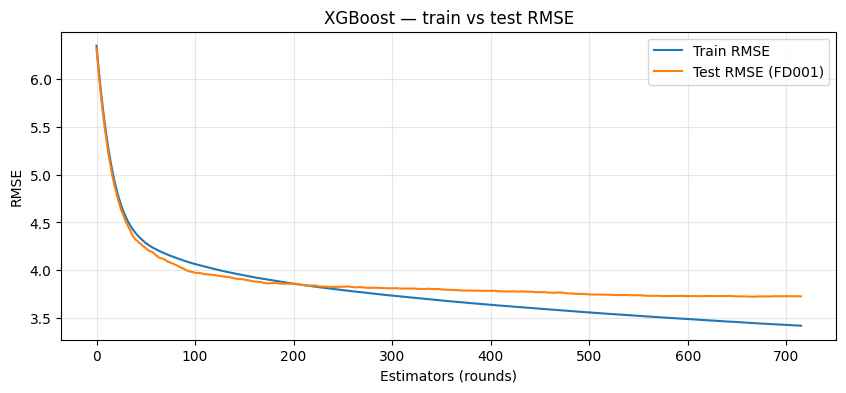

Final train RMSE : 3.42
Final test RMSE  : 3.73
Gap              : 0.31


In [15]:
results_log = model.evals_result()
train_rmse  = np.sqrt(results_log['validation_0']['rmse'])
test_rmse   = np.sqrt(results_log['validation_1']['rmse'])

plt.figure(figsize=(10, 4))
plt.plot(train_rmse, label='Train RMSE')
plt.plot(test_rmse,  label='Test RMSE (FD001)')
plt.xlabel('Estimators (rounds)')
plt.ylabel('RMSE')
plt.title('XGBoost — train vs test RMSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f'Final train RMSE : {train_rmse[-1]:.2f}')
print(f'Final test RMSE  : {test_rmse[-1]:.2f}')
print(f'Gap              : {test_rmse[-1] - train_rmse[-1]:.2f}')

In [16]:
results = {}

for subset in SUBSETS:
    X, y_true = test_flat[subset], test_data[subset][1]
    y_pred = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    results[subset] = {'y_true': y_true, 'y_pred': y_pred, 'rmse': rmse}
    print(f'{subset} RMSE: {rmse:.2f} cycles')

# Weighted average RMSE across all subsets
all_true = np.concatenate([results[s]['y_true'] for s in SUBSETS])
all_pred = np.concatenate([results[s]['y_pred'] for s in SUBSETS])
combined_rmse = np.sqrt(mean_squared_error(all_true, all_pred))
print(f'\nCombined RMSE (all subsets): {combined_rmse:.2f} cycles')
print(f'FD001 baseline (single-condition model): 14.26 cycles')

FD001 RMSE: 13.86 cycles
FD002 RMSE: 16.95 cycles
FD003 RMSE: 15.30 cycles
FD004 RMSE: 23.23 cycles

Combined RMSE (all subsets): 18.84 cycles
FD001 baseline (single-condition model): 14.26 cycles


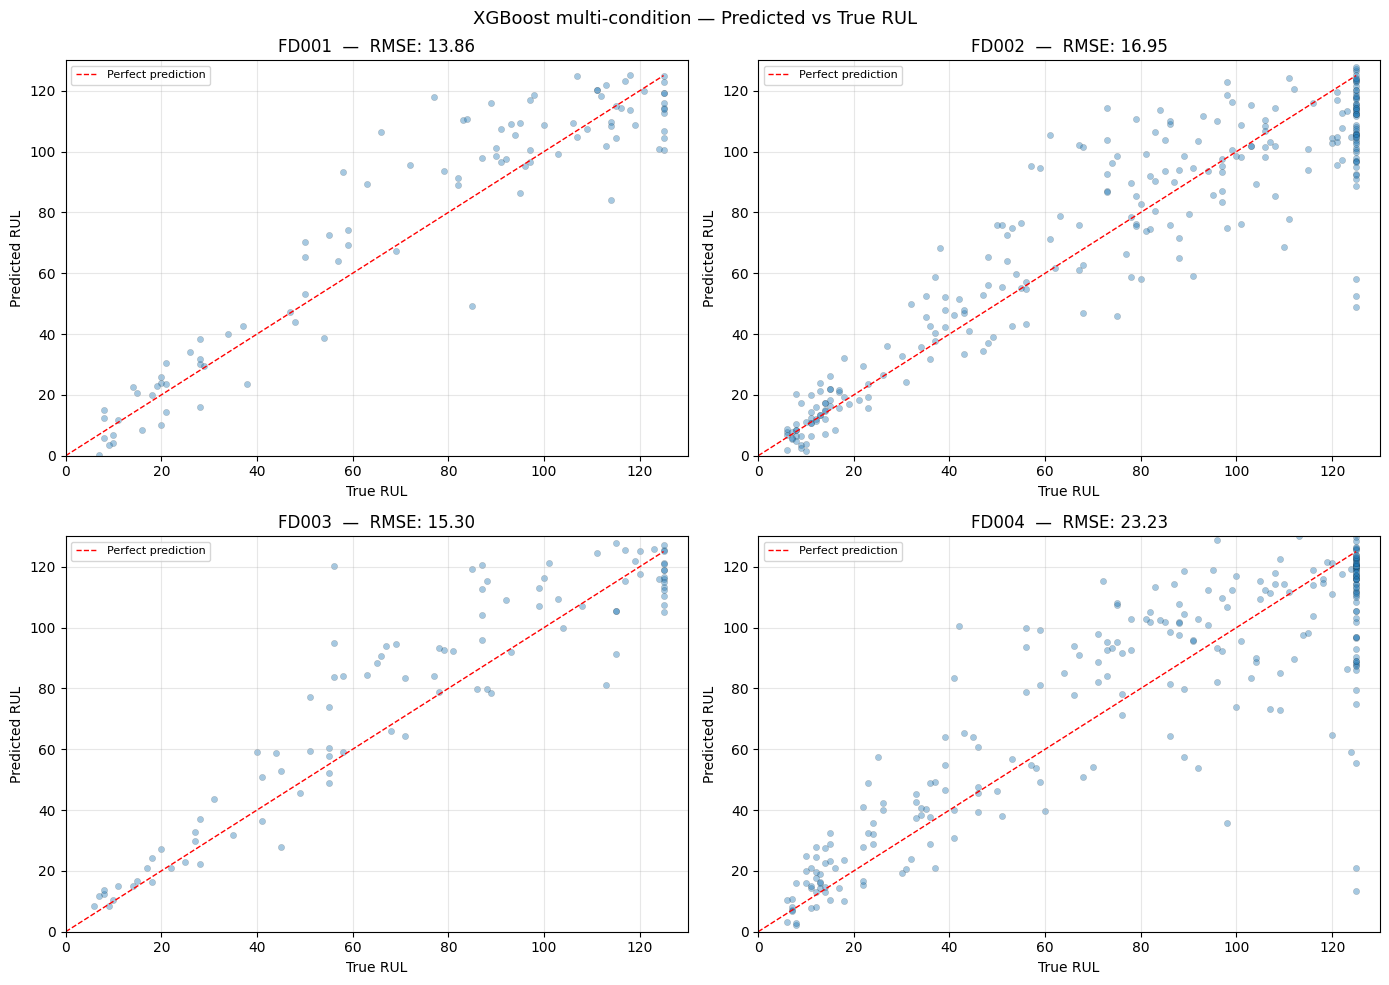

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, subset in zip(axes, SUBSETS):
    y_true = results[subset]['y_true']
    y_pred = results[subset]['y_pred']
    rmse   = results[subset]['rmse']

    ax.scatter(y_true, y_pred, alpha=0.4, edgecolors='k', linewidth=0.2, s=20)
    ax.plot([0, 125], [0, 125], 'r--', linewidth=1, label='Perfect prediction')
    ax.set_xlabel('True RUL')
    ax.set_ylabel('Predicted RUL')
    ax.set_title(f'{subset}  —  RMSE: {rmse:.2f}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 130)
    ax.set_ylim(0, 130)

plt.suptitle('XGBoost multi-condition — Predicted vs True RUL', fontsize=13)
plt.tight_layout()
plt.show()

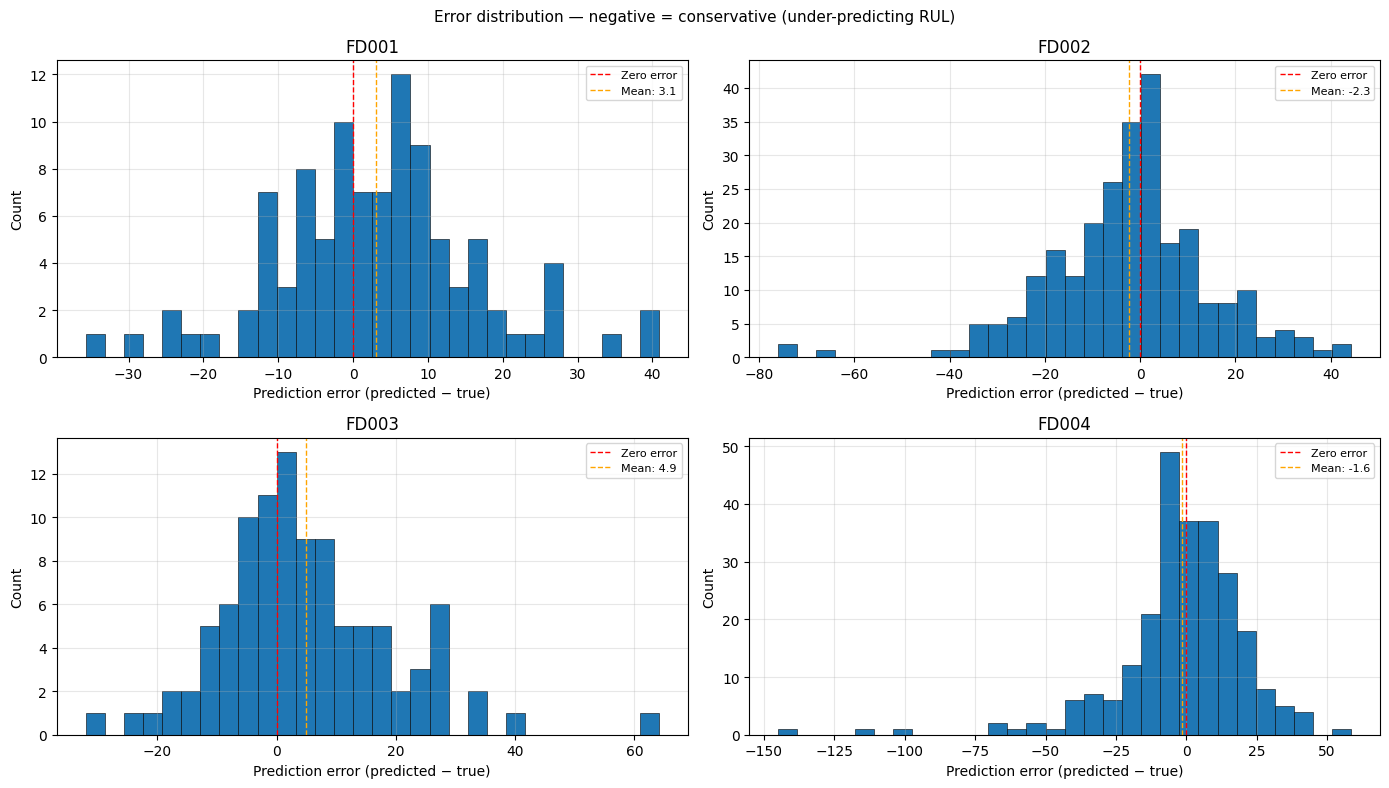

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, subset in zip(axes, SUBSETS):
    errors = results[subset]['y_pred'] - results[subset]['y_true']
    ax.hist(errors, bins=30, edgecolor='black', linewidth=0.4)
    ax.axvline(0,             color='red',    linestyle='--', linewidth=1, label='Zero error')
    ax.axvline(errors.mean(), color='orange', linestyle='--', linewidth=1,
               label=f'Mean: {errors.mean():.1f}')
    ax.set_title(subset)
    ax.set_xlabel('Prediction error (predicted − true)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Error distribution — negative = conservative (under-predicting RUL)', fontsize=11)
plt.tight_layout()
plt.show()

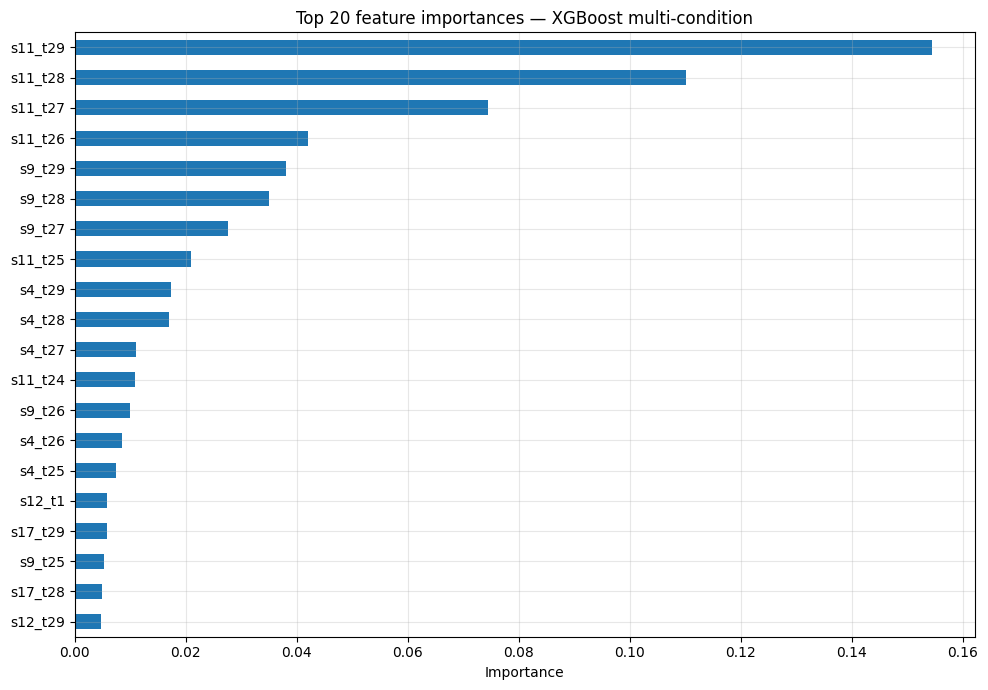

Top 10 features:
s11_t29    0.154437
s11_t28    0.110126
s11_t27    0.074374
s11_t26    0.041982
s9_t29     0.038136
s9_t28     0.035064
s9_t27     0.027692
s11_t25    0.020903
s4_t29     0.017404
s4_t28     0.016965


In [19]:
USEFUL_SENSORS = ['s2','s3','s4','s7','s8','s9','s11',
                  's12','s13','s14','s15','s17','s20','s21']
WINDOW_SIZE = 30

feature_names = [f'{sensor}_t{cycle}'
                 for cycle in range(WINDOW_SIZE)
                 for sensor in USEFUL_SENSORS]

importances = pd.Series(model.feature_importances_, index=feature_names)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top20.sort_values().plot(kind='barh', ax=ax)
ax.set_title('Top 20 feature importances — XGBoost multi-condition')
ax.set_xlabel('Importance')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(top20.head(10).to_string())

In [20]:
print('='*55)
print('  XGBoost Results Summary')
print('='*55)
print(f'  {"Model":<35} {"RMSE":>8}')
print('-'*55)
print(f'  {"XGBoost — FD001 only (notebook 04)":<35} {"14.26":>8}')
for subset in SUBSETS:
    rmse = results[subset]["rmse"]
    print(f'  {"XGBoost multi — " + subset:<35} {rmse:>8.2f}')
print(f'  {"XGBoost multi — combined":<35} {combined_rmse:>8.2f}')
print('='*55)

  XGBoost Results Summary
  Model                                   RMSE
-------------------------------------------------------
  XGBoost — FD001 only (notebook 04)     14.26
  XGBoost multi — FD001                  13.86
  XGBoost multi — FD002                  16.95
  XGBoost multi — FD003                  15.30
  XGBoost multi — FD004                  23.23
  XGBoost multi — combined               18.84


In [21]:
with open('../models/xgb_multi.pkl', 'wb') as f:
    pickle.dump(model, f)

print('Model saved to ../models/xgb_multi.pkl')

Model saved to ../models/xgb_multi.pkl
